La cadena de gimnasios FitLife ha recopilado información de cientos de socios con el objetivo de comprender mejor qué factores influyen en el gasto calórico durante una sesión de entrenamiento.

In [1]:
import pandas as pd
link= "https://raw.githubusercontent.com/xcaret045-bit/EstadisticaVerano2026/refs/heads/main/Gym%20members/gym_members_exercise_tracking.csv"
df=pd.read_csv(link)
df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [2]:
df.rename(
    columns={
        "Session_Duration (hours)": "duracion_sesion_hrs",
        "Calories_Burned": "calorias_quemadas",
        "Gender": "genero",
        "Workout_Type": "tipo_entrenamiento",
        "Experience_Level": "nivel_experiencia",
        "Workout_Frequency (days/week)": "frecuencia_dias",
        "Age": "edad"
    },
    inplace=True
)

df

,edad,genero,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,duracion_sesion_hrs,calorias_quemadas,tipo_entrenamiento,Fat_Percentage,Water_Intake (liters),frecuencia_dias,nivel_experiencia,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   edad                   973 non-null    int64  
 1   genero                 973 non-null    object 
 2   Weight (kg)            973 non-null    float64
 3   Height (m)             973 non-null    float64
 4   Max_BPM                973 non-null    int64  
 5   Avg_BPM                973 non-null    int64  
 6   Resting_BPM            973 non-null    int64  
 7   duracion_sesion_hrs    973 non-null    float64
 8   calorias_quemadas      973 non-null    float64
 9   tipo_entrenamiento     973 non-null    object 
 10  Fat_Percentage         973 non-null    float64
 11  Water_Intake (liters)  973 non-null    float64
 12  frecuencia_dias        973 non-null    int64  
 13  nivel_experiencia      973 non-null    int64  
 14  BMI                    973 non-null    float64
dtypes: flo

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Female   Male  82.2071   0.0 48.2331 116.181   True
---------------------------------------------------


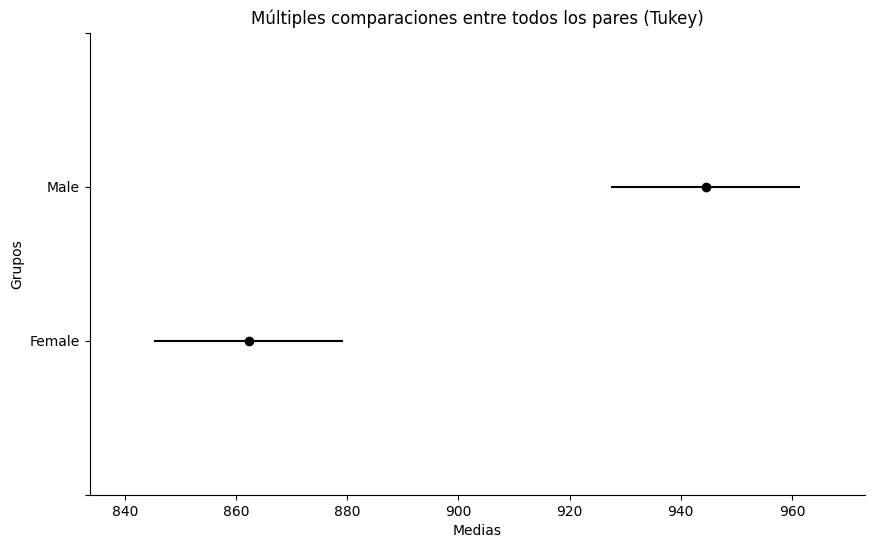

In [4]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
                                      #y                   #categorica
tukey = pairwise_tukeyhsd(endog=df['calorias_quemadas'], groups=df['genero'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

  #Guardar imagen
plt.savefig(
            "Dispersión",
            bbox_inches="tight"
)

Se ordenan de menor a mayor:

Female
Male

In [5]:
df["genero"]=df["genero"].map({"Female":0,"Male":1})
df

,edad,genero,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,duracion_sesion_hrs,calorias_quemadas,tipo_entrenamiento,Fat_Percentage,Water_Intake (liters),frecuencia_dias,nivel_experiencia,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1   group2  meandiff p-adj   lower    upper   reject
----------------------------------------------------------
  Cardio     HIIT  41.2917 0.3523 -23.1974 105.7809  False
  Cardio Strength  26.1839 0.6973 -35.7784  88.1463  False
  Cardio     Yoga  18.6746 0.8721 -44.5002  81.8494  False
    HIIT Strength -15.1078 0.9306 -79.4226  49.2071  False
    HIIT     Yoga -22.6171 0.8107 -88.1009  42.8666  False
Strength     Yoga  -7.5094   0.99 -70.5062  55.4875  False
----------------------------------------------------------


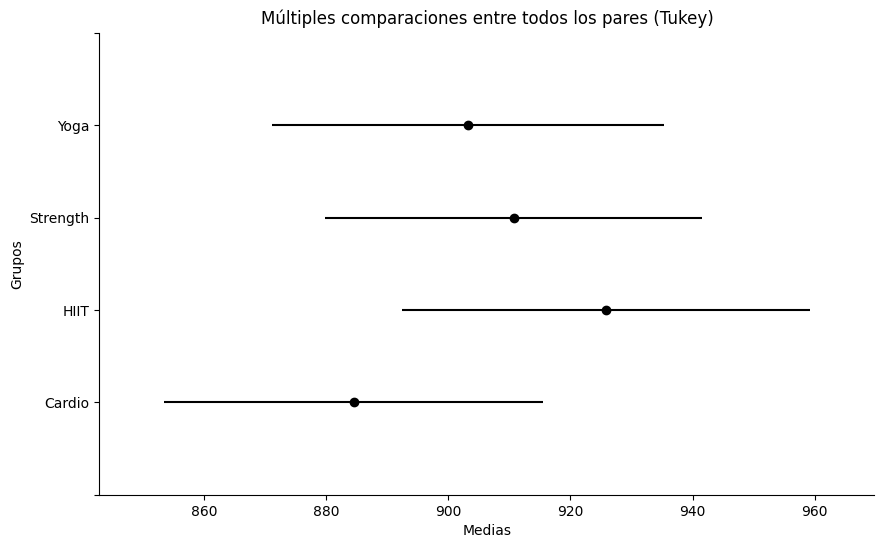

In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
                                      #y                   #categorica
tukey = pairwise_tukeyhsd(endog=df['calorias_quemadas'], groups=df['tipo_entrenamiento'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Guardar imagen
plt.savefig(
            "Dispersión",
            bbox_inches="tight"
)

Se ordenan de menor a mayor:



*   Cardio
*   Yoga
*   Strength
*   HIIT





In [7]:
df["tipo_entrenamiento"]=df["tipo_entrenamiento"].map({"Cardio":0,"Yoga":1,"Strength":2,"HIIT":3})
df

,edad,genero,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,duracion_sesion_hrs,calorias_quemadas,tipo_entrenamiento,Fat_Percentage,Water_Intake (liters),frecuencia_dias,nivel_experiencia,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,1,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,3,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,2,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,2,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,0,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,3,28.2,2.1,3,2,37.74


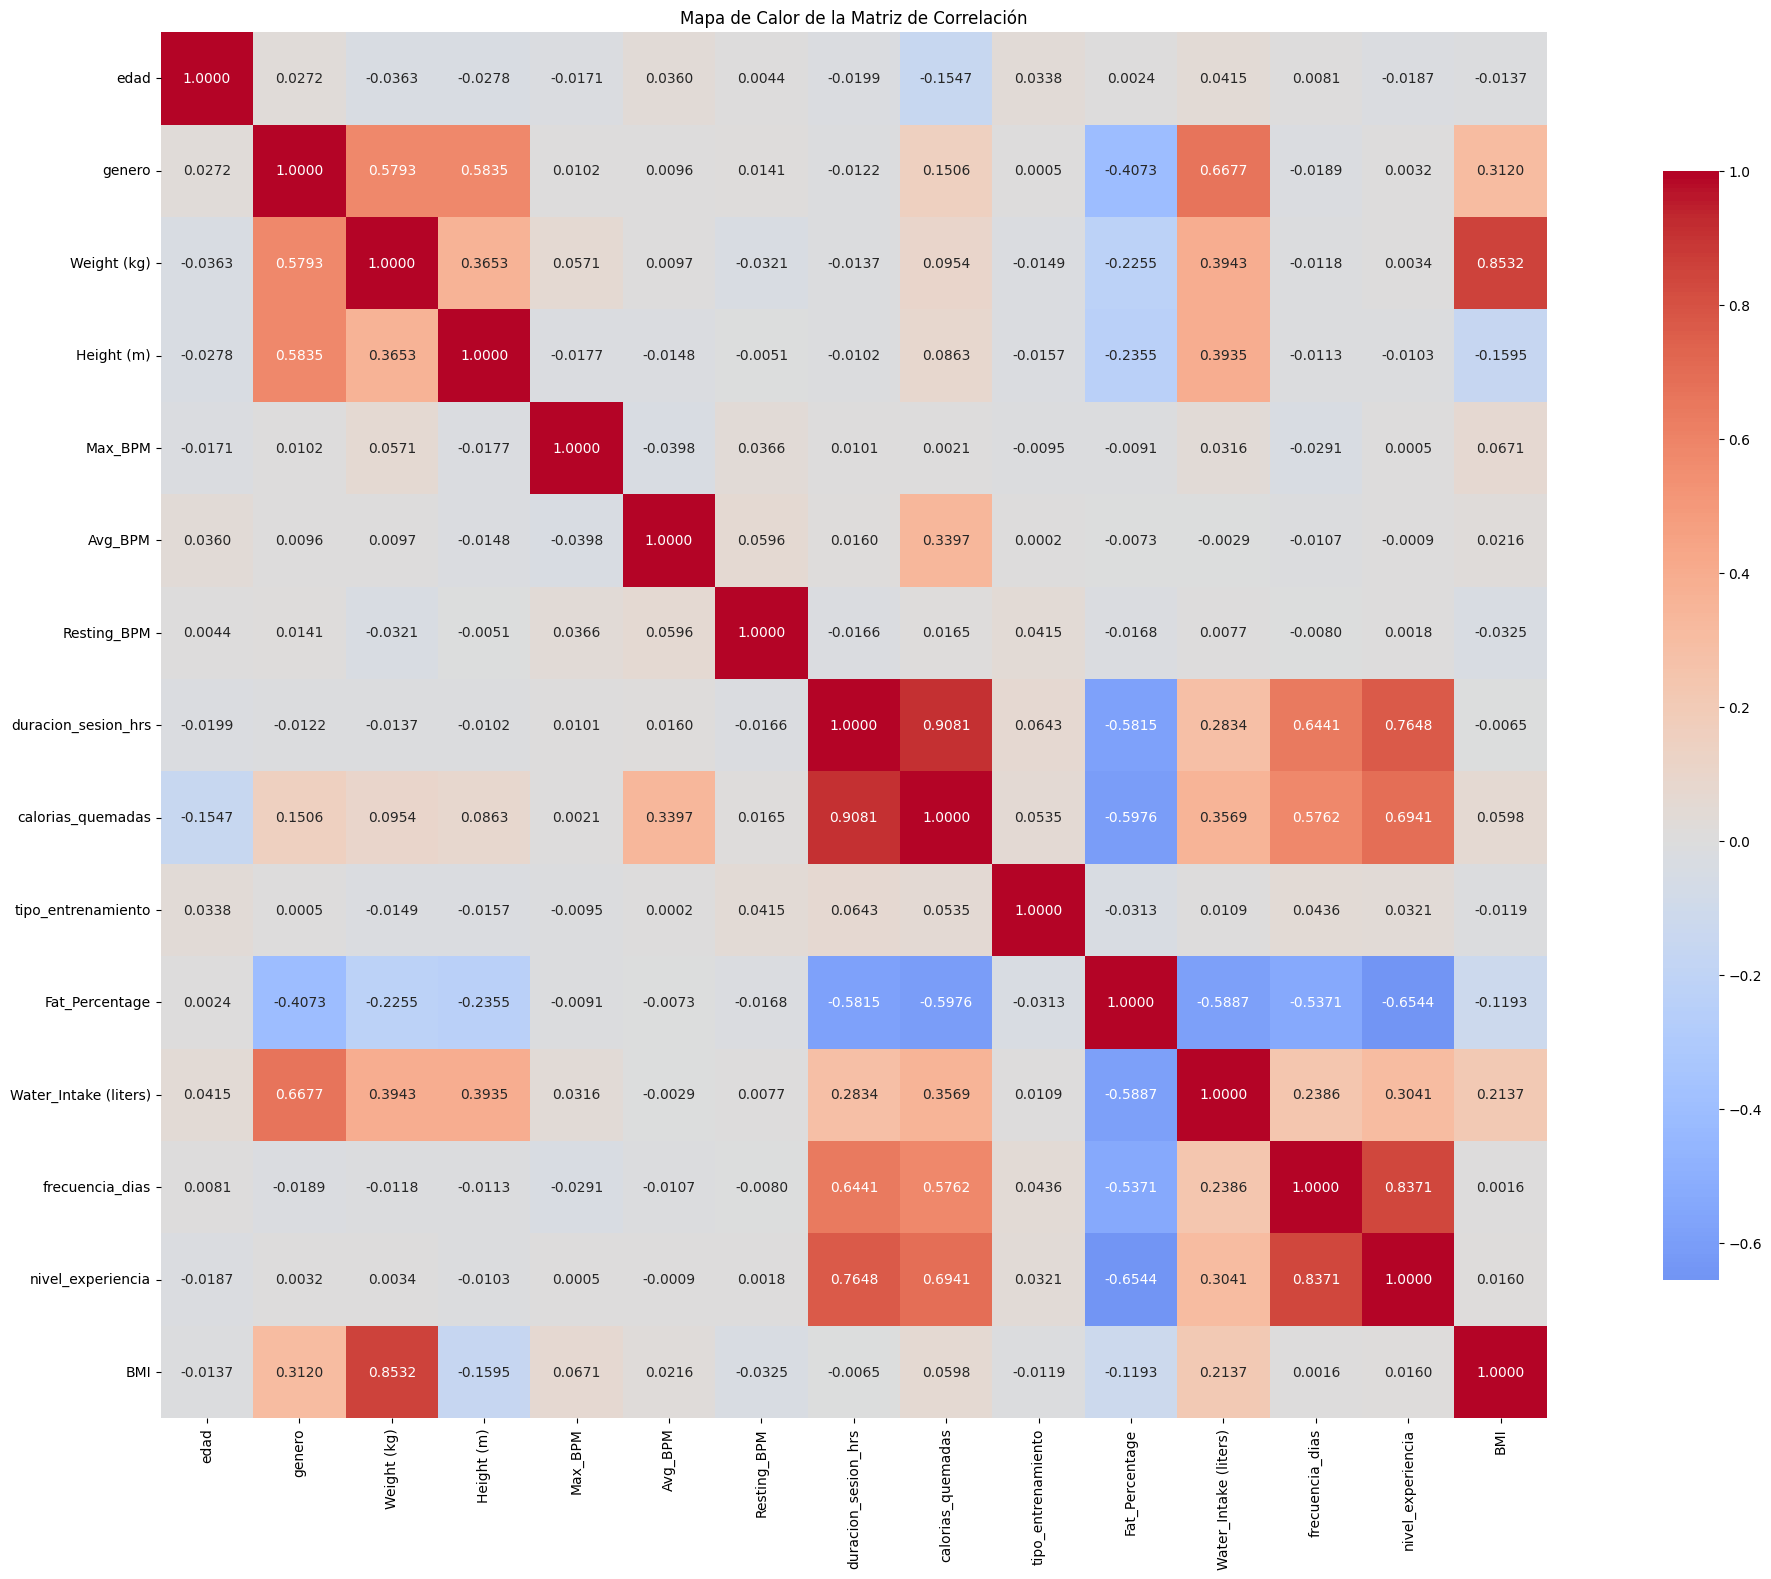

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()
plt.figure(figsize=(30, 18))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".4f",
            square=True,
            center=0,
            cbar_kws={"shrink": .8})
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

Quitamos las que son muy intrusivas o personales

peso,altura,max_bpm,promedio_bpm,reposo_bpm,porcentaje_grasa,agua,imc

In [10]:
df=df[["duracion_sesion_hrs","nivel_experiencia","frecuencia_dias","genero","edad","calorias_quemadas"]]
df

,duracion_sesion_hrs,nivel_experiencia,frecuencia_dias,genero,edad,calorias_quemadas
0,1.69,3,4,1,56,1313.0
1,1.30,2,4,0,46,883.0
2,1.11,2,4,0,32,677.0
3,0.59,1,3,1,25,532.0
4,0.64,1,3,1,38,556.0
...,...,...,...,...,...,...
968,1.57,3,4,1,24,1364.0
969,1.38,1,2,1,25,1260.0
970,1.72,3,5,0,59,929.0
971,1.10,2,3,1,32,883.0


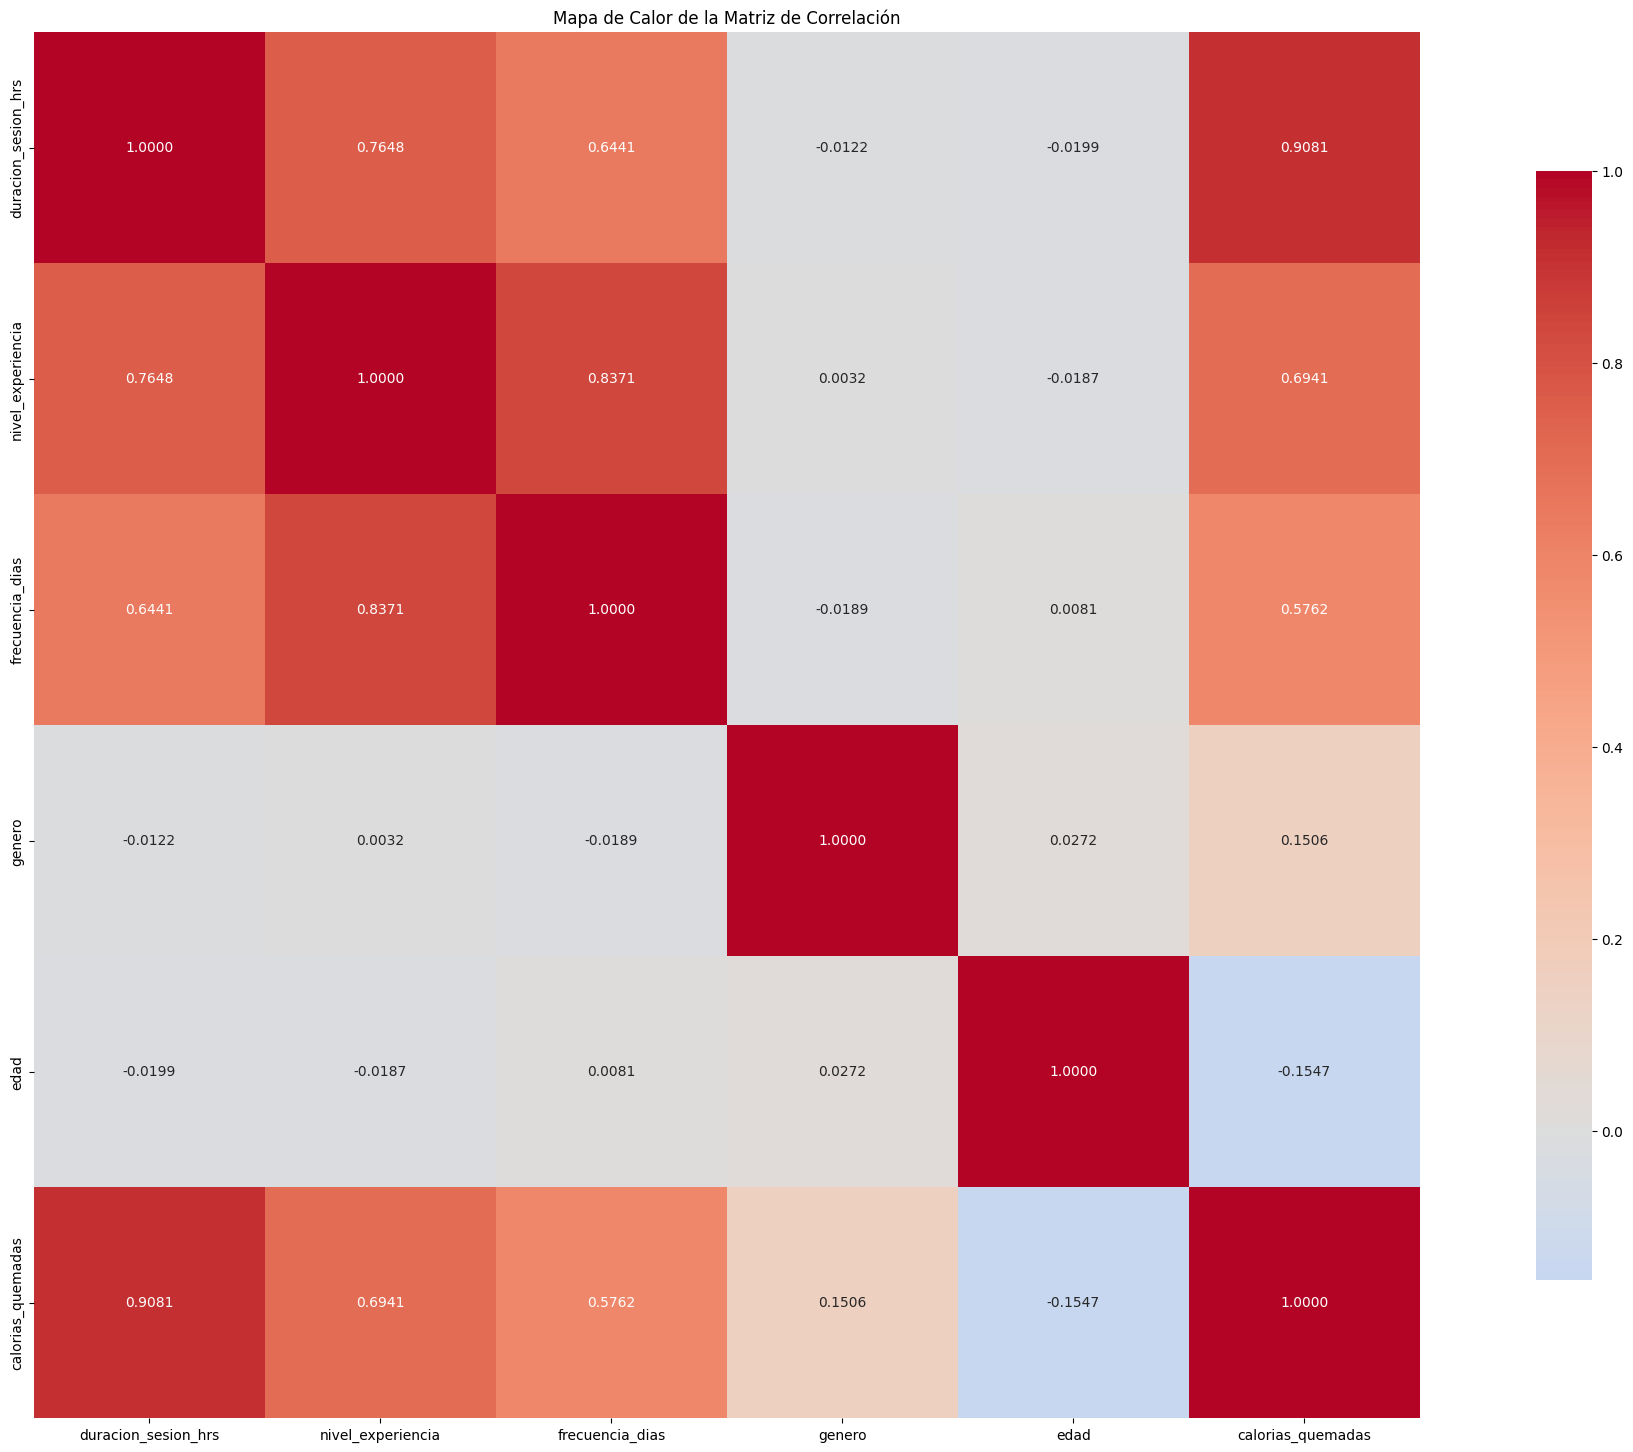

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()
plt.figure(figsize=(30, 18))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".4f",
            square=True,
            center=0,
            cbar_kws={"shrink": .8})
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

In [12]:
x=df[["duracion_sesion_hrs","frecuencia_dias","genero","edad"]]
y=df["calorias_quemadas"]

In [13]:
import statsmodels.api as sm
x_constante=sm.add_constant(x)
modelo=sm.OLS(y,x_constante).fit()
y_calculada=modelo.predict(x_constante)
modelo.params

,0
const,76.383259
duracion_sesion_hrs,724.702457
frecuencia_dias,-2.066399
genero,90.296443
edad,-3.155146


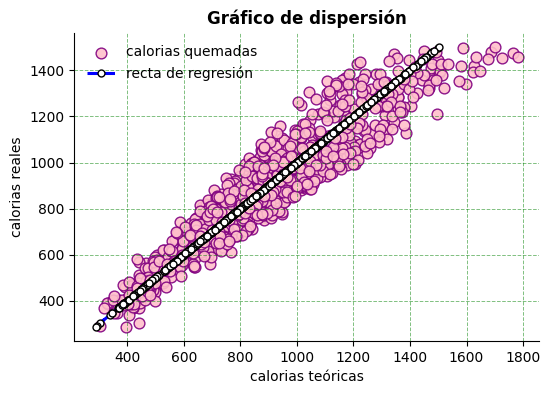

In [14]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
#configuración general
plt.figure(
    figsize=(6,4),  #tamaño (ancho, alto)
    dpi=100         #resolución
)
#Gráfico de dispersión
plt.scatter(
    y, y_calculada,
    marker="o",
    color="pink",
    edgecolor="purple", #color de borde
    alpha=0.9, #transparencia
    s=60, #tamaño de punto
    label="calorias quemadas" #etiqueta
)

plt.plot(
    y_calculada,y_calculada,
    marker="o",
    color="blue",
    linewidth=2.2,
    linestyle="--",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor="black",
    label="recta de regresión"

)

#Título
plt.title(
    "Gráfico de dispersión",
    fontsize=12, #tamaño de fuente
    fontweight="bold" #bold:negritas
)
#Etiquetas eje x
plt.xlabel(
    "calorias teóricas",
    fontsize=10,
)
#Etiqueta eje y
plt.ylabel(
    "calorias reales",
    fontsize=10
)
#tamaño de los tricks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

#Márgenes
plt.margins(x=0.05,y=0.05)
plt.gca().spines[["top","right"]].set_visible(False)

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7, #ancho de line
    alpha=0.5, #transparencia
    color="green"
)
    #Leyenda
plt.legend(
        fontsize=10,
        loc="best",
        frameon=False
        #bbox_to_anchor=(0.5.-0.15)
)
        #Guardar imagen
plt.savefig(
            "Dispersión",
            bbox_inches="tight"
        )

In [15]:
from sklearn.metrics import r2_score
r2=r2_score(y,y_calculada)
print(f"Coeficiente de determinación: {r2:0.2%}\n")

Coeficiente de determinación: 87.08%



El modelo explica a un 87.08% la variación de la variable dependiente.
Esta justificando al 87.08% la variabilidad

In [16]:
#Obtenga un intervalo de confianza del 95% para la pendiente de la recta de
#regresión ajustada ( 𝑏1 )
modelo.conf_int(alpha = 0.05)

,0,1
const,43.356599,109.409919
duracion_sesion_hrs,701.131745,748.273169
frecuencia_dias,-10.921509,6.788712
genero,77.917543,102.675343
edad,-3.663088,-2.647204


In [17]:
residuales=modelo.resid

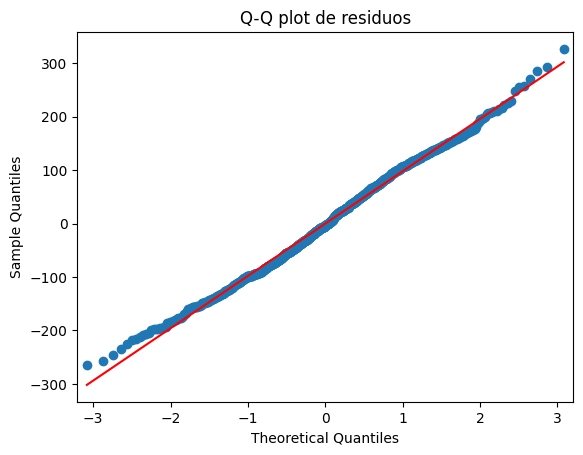

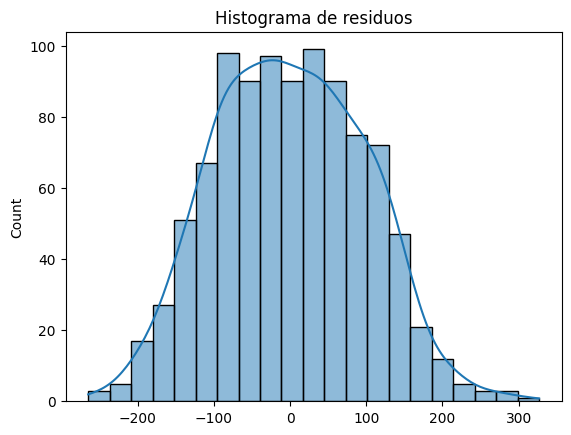

In [18]:
#Histograma y Q-Q plot
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns



# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [19]:
#Test de Breusch-Pagan
from statsmodels.stats.api import het_breuschpagan
estadistico_1, valor_p_1, estadistico_2, valor_p_2 = het_breuschpagan(residuales, x_constante)
print(f"valor_p:{valor_p_1:0.4f}")
# Ho: No hay heterocedasticidad (varianza uniforme)
# H1: Hay heterocedasticidad (varianza no uniforme)
# Como el valor p es mayor a el nivel de significancia, entoces la Ho es verdadera
# No hay heterocedasticidad, por lo tanto, hay homocedasticidad o la varianza es uniforme

valor_p:0.0000


Como el valor p es menor al nivel de significacia, entonces H0
es falsa, por lo tanto, hay heterocedasticidad y la varianza no es uniforme.

In [20]:
df.describe()

,duracion_sesion_hrs,nivel_experiencia,frecuencia_dias,genero,edad,calorias_quemadas
count,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,1.256423,1.809866,3.321686,0.525180,38.683453,905.422405
std,0.343033,0.739693,0.913047,0.499622,12.180928,272.641516
min,0.500000,1.000000,2.000000,0.000000,18.000000,303.000000
25%,1.040000,1.000000,3.000000,0.000000,28.000000,720.000000
50%,1.260000,2.000000,3.000000,1.000000,40.000000,893.000000
75%,1.460000,2.000000,4.000000,1.000000,49.000000,1076.000000
max,2.000000,3.000000,5.000000,1.000000,59.000000,1783.000000


In [21]:
#Realice una tabla ANOVA e interprete el resultado.
from statsmodels.formula.api import ols
# y ~ x
modelo_lineal=ols("calorias_quemadas~duracion_sesion_hrs+frecuencia_dias+genero+edad", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
duracion_sesion_hrs,1.0,5.958764e+07,5.958764e+07,6178.813317,0.000000e+00
frecuencia_dias,1.0,9.606055e+03,9.606055e+03,0.996079,3.185105e-01
genero,1.0,1.886554e+06,1.886554e+06,195.622211,1.272222e-40
edad,1.0,1.432996e+06,1.432996e+06,148.591438,6.711290e-32
Residual,968.0,9.335262e+06,9.643865e+03,NaN,NaN




*   Duración=0.0000 ---- > SÍ HAY CORRELACIÓN
*   Frecuencia=0.3185 ---- > NO HAY CORRELACIÓN
*   Genero=0.0000 ---- > SÍ HAY CORRELACIÓN
*   Edad=0.00000 ---- > SÍ HAY CORRELACIÓN
Se puede ignorar la variable que no tiene correlación, o se repite el analisis pero quitando la variable de frecuencia







In [22]:
#Realice una tabla ANOVA e interprete el resultado.
from statsmodels.formula.api import ols
# y ~ x
modelo_lineal=ols("calorias_quemadas~duracion_sesion_hrs+genero+edad", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
tabla_anova.round(4)

,df,sum_sq,mean_sq,F,PR(>F)
duracion_sesion_hrs,1.0,5.958764e+07,5.958764e+07,6183.8567,0.0
genero,1.0,1.890050e+06,1.890050e+06,196.1447,0.0
edad,1.0,1.437084e+06,1.437084e+06,149.1369,0.0
Residual,969.0,9.337284e+06,9.636000e+03,NaN,NaN


Todas las variables tienen correlación, el modelo es significativo.

In [23]:
df=df[["duracion_sesion_hrs","genero","edad","calorias_quemadas"]]
df

,duracion_sesion_hrs,genero,edad,calorias_quemadas
0,1.69,1,56,1313.0
1,1.30,0,46,883.0
2,1.11,0,32,677.0
3,0.59,1,25,532.0
4,0.64,1,38,556.0
...,...,...,...,...
968,1.57,1,24,1364.0
969,1.38,1,25,1260.0
970,1.72,0,59,929.0
971,1.10,1,32,883.0


In [24]:
#Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
import statsmodels.api as sm
x_constante=sm.add_constant(x)
modelo=sm.OLS(y,x_constante).fit()
y_calculada=modelo.predict(x_constante)
modelo.params

,0
const,76.383259
duracion_sesion_hrs,724.702457
frecuencia_dias,-2.066399
genero,90.296443
edad,-3.155146


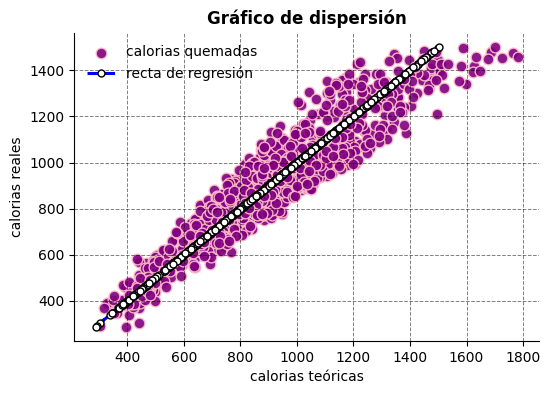

In [25]:
#grafíquelo sobre el gráfico de dispersión.

from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
#configuración general
plt.figure(
    figsize=(6,4),  #tamaño (ancho, alto)
    dpi=100         #resolución
)
#Gráfico de dispersión
plt.scatter(
    y, y_calculada,
    marker="o",
    color="purple",
    edgecolor="pink", #color de borde
    alpha=0.9, #transparencia
    s=60, #tamaño de punto
    label="calorias quemadas" #etiqueta
)

plt.plot(
    y_calculada,y_calculada,
    marker="o",
    color="blue",
    linewidth=2.2,
    linestyle="--",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor="black",
    label="recta de regresión"

)

#Título
plt.title(
    "Gráfico de dispersión",
    fontsize=12, #tamaño de fuente
    fontweight="bold" #bold:negritas
)
#Etiquetas eje x
plt.xlabel(
    "calorias teóricas",
    fontsize=10,
)
#Etiqueta eje y
plt.ylabel(
    "calorias reales",
    fontsize=10
)
#tamaño de los tricks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

#Márgenes
plt.margins(x=0.05,y=0.05)
plt.gca().spines[["top","right"]].set_visible(False)

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7, #ancho de line
    alpha=0.5, #transparencia
    color="black"
)
    #Leyenda
plt.legend(
        fontsize=10,
        loc="best",
        frameon=False
        #bbox_to_anchor=(0.5.-0.15)
)
        #Guardar imagen
plt.savefig(
            "Dispersión",
            bbox_inches="tight"
        )

In [26]:
from sklearn.metrics import r2_score
r2=r2_score(y,y_calculada)
print(f"Coeficiente de determinación: {r2:0.2%}\n")

Coeficiente de determinación: 87.08%



El modelo explica a un 87.08% la variación de la variable dependiente.
Esta justificando al 87.08% la variabilidad

In [27]:
#Obtenga un intervalo de confianza del 95% para la pendiente de la recta de
#regresión ajustada ( 𝑏1 )
modelo.conf_int(alpha = 0.05)

,0,1
const,43.356599,109.409919
duracion_sesion_hrs,701.131745,748.273169
frecuencia_dias,-10.921509,6.788712
genero,77.917543,102.675343
edad,-3.663088,-2.647204


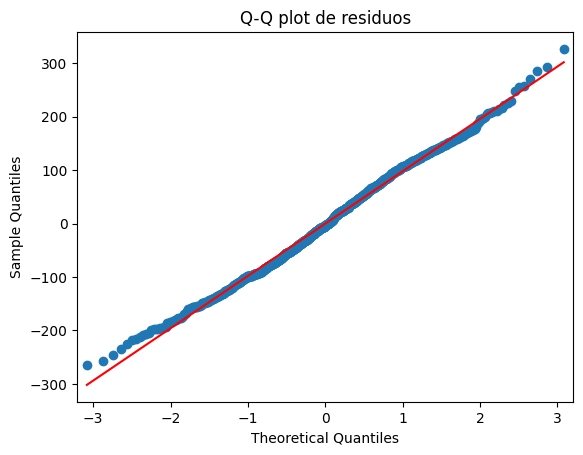

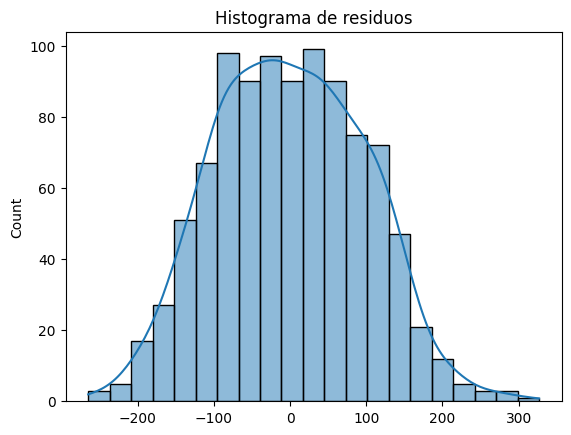

In [28]:
#Histograma y Q-Q plot
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns


# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [29]:
#Test de Breusch-Pagan
from statsmodels.stats.api import het_breuschpagan
estadistico_1, valor_p_1, estadistico_2, valor_p_2 = het_breuschpagan(residuales, x_constante)
print(f"valor_p:{valor_p_1:0.4f}")
# Ho: No hay heterocedasticidad (varianza uniforme)
# H1: Hay heterocedasticidad (varianza no uniforme)
# Como el valor p es mayor a el nivel de significancia, entoces la Ho es verdadera
# No hay heterocedasticidad, por lo tanto, hay homocedasticidad o la varianza es uniforme

valor_p:0.0000


Como el valor p es menor al nivel de significacia,entonces H0 es falsa
Por lo tanto, hay heterocedasticidad y la varianza no es uniforme

In [30]:
df.describe()

,duracion_sesion_hrs,genero,edad,calorias_quemadas
count,973.000000,973.000000,973.000000,973.000000
mean,1.256423,0.525180,38.683453,905.422405
std,0.343033,0.499622,12.180928,272.641516
min,0.500000,0.000000,18.000000,303.000000
25%,1.040000,0.000000,28.000000,720.000000
50%,1.260000,1.000000,40.000000,893.000000
75%,1.460000,1.000000,49.000000,1076.000000
max,2.000000,1.000000,59.000000,1783.000000


Si el modeo no cumple con los 3 supuestos (linealidad, homocedasticidad,linealidad) se invalidan los intervalos de confianza